In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
edf = pd.read_csv("/content/drive/MyDrive/WIRELESSCOM/wirelesscode/raw_data/feature_matrix.csv")
tdf = pd.read_csv("/content/drive/MyDrive/WIRELESSCOM/wirelesscode/raw_data/output_matrix.csv")

In [ ]:
print(tdf.shape, edf.shape)

(57586, 5) (57586, 11)


In [ ]:
tdf.columns

Index(['Unnamed: 0', 'SINR', 'RSRP', 'RSRQ', 'Power'], dtype='object')

In [ ]:
df = pd.concat([edf, tdf], axis=1)

In [ ]:
df.shape

(57586, 16)

In [ ]:
df['RSRP'].max()

-53.47

In [ ]:
df['RSRP'].min()

-142.95

In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
Longitude,0
Latitude,0
Speed,0
Distance,0
Distance_x,0
Distance_y,0
PCI,0
PCI_64,0
PCI_65,0


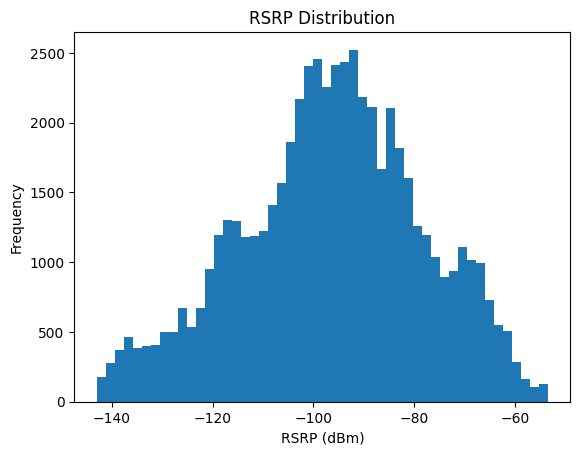

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['RSRP'], bins=50)
plt.title("RSRP Distribution")
plt.xlabel("RSRP (dBm)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df_sampled['RSRP'], bins=50)
plt.title("RSRP Distribution")
plt.xlabel("RSRP (dBm)")
plt.ylabel("Frequency")
plt.show()

NameError: name 'df_sampled' is not defined

<Figure size 640x480 with 0 Axes>

In [ ]:
# Step 1: Create bins (important!)
df['RSRP_bin'] = pd.qcut(df['RSRP'], q=10, duplicates='drop')
# 10 bins (you can change this)

# Step 2: Stratified sampling
df_sampled = df.groupby('RSRP_bin', group_keys=False).apply(
    lambda x: x.sample(frac=1000/len(df), random_state=42)
)

# Step 3: Drop bin column
df_sampled = df_sampled.drop(columns=['RSRP_bin'])

# Final dataset
feat_sampled = df_sampled.drop(columns=['RSRP'])
y_sampled = df_sampled['RSRP']

/tmp/ipykernel_1625/2510516938.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_sampled = df.groupby('RSRP_bin', group_keys=False).apply(
/tmp/ipykernel_1625/2510516938.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df.groupby('RSRP_bin', group_keys=False).apply(


In [ ]:
df_sampled = df_sampled.drop(["Unnamed: 0"], axis=1)

In [ ]:
df_sampled = df_sampled.reset_index()

In [ ]:
df_sampled = df_sampled.drop(["PCI_64","PCI_65","PCI_302"], axis=1)

In [ ]:
df_sampled['PCI'].value_counts()

,count
PCI,
302,414
65,381
64,205


In [ ]:
df_sampled

,index,Longitude,Latitude,Speed,Distance,Distance_x,Distance_y,PCI,SINR,RSRP,RSRQ,Power
0,53735,12.513810,55.781135,15.88,0.721475,-0.003535,-0.009671,302,2.22,-124.83,-19.01,-101.69
1,56186,12.528917,55.795474,0.87,1.248863,0.010804,0.005436,302,-11.89,-136.53,-26.04,-116.13
2,52546,12.527072,55.795562,13.57,1.232131,0.010892,0.003591,302,-9.37,-133.63,-21.89,-113.93
3,54201,12.529027,55.792470,34.42,0.934332,0.007800,0.005546,302,-14.57,-135.14,-25.41,-115.78
4,56261,12.528338,55.790267,54.89,0.692687,0.005597,0.004857,302,1.35,-123.17,-21.36,-97.43
...,...,...,...,...,...,...,...,...,...,...,...,...
995,19467,12.520928,55.785577,12.03,0.188864,0.000907,-0.002553,65,22.00,-66.86,-13.09,-46.22
996,18596,12.517096,55.785698,5.37,0.415386,0.001028,-0.006385,65,28.98,-64.20,-13.05,-42.71
997,913,12.520875,55.781393,8.31,0.399306,-0.003277,-0.002606,64,22.71,-70.80,-13.04,-50.22
998,4911,12.523993,55.784551,12.74,0.034659,-0.000119,0.000512,64,7.57,-71.21,-15.12,-48.90


In [ ]:
df_sampled.to_csv("/content/drive/MyDrive/WIRELESSCOM/dataset_with_power_1000.csv")

In [ ]:
#mapping
pci_to_freq = {
    64: 0.811,
    65: 0.811,
    302: 2.63
}

In [ ]:
df_sampled['frequency'] = df_sampled['PCI'].map(pci_to_freq)

In [ ]:
df_sampled

,index,Longitude,Latitude,Speed,Distance,Distance_x,Distance_y,PCI,SINR,RSRP,RSRQ,Power,frequency
0,53735,12.513810,55.781135,15.88,0.721475,-0.003535,-0.009671,302,2.22,-124.83,-19.01,-101.69,2.630
1,56186,12.528917,55.795474,0.87,1.248863,0.010804,0.005436,302,-11.89,-136.53,-26.04,-116.13,2.630
2,52546,12.527072,55.795562,13.57,1.232131,0.010892,0.003591,302,-9.37,-133.63,-21.89,-113.93,2.630
3,54201,12.529027,55.792470,34.42,0.934332,0.007800,0.005546,302,-14.57,-135.14,-25.41,-115.78,2.630
4,56261,12.528338,55.790267,54.89,0.692687,0.005597,0.004857,302,1.35,-123.17,-21.36,-97.43,2.630
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,19467,12.520928,55.785577,12.03,0.188864,0.000907,-0.002553,65,22.00,-66.86,-13.09,-46.22,0.811
996,18596,12.517096,55.785698,5.37,0.415386,0.001028,-0.006385,65,28.98,-64.20,-13.05,-42.71,0.811
997,913,12.520875,55.781393,8.31,0.399306,-0.003277,-0.002606,64,22.71,-70.80,-13.04,-50.22,0.811
998,4911,12.523993,55.784551,12.74,0.034659,-0.000119,0.000512,64,7.57,-71.21,-15.12,-48.90,0.811


In [ ]:
from scipy.constants import speed_of_light
import numpy as np
import matplotlib.pyplot as plt

def uma_los(d3d, d2d, dbp, fc, h_b, h_t):
    # 38.901 UMa LOS
    PL1 = 28+22*np.log10(d3d)+20*np.log10(fc)
    PL2 = 28+40*np.log10(d3d)+20*np.log10(fc) - 9*np.log10(dbp**2+(h_b - h_t)**2)
    PL = np.zeros((d3d.shape))
    PL = PL2 # Default pathloss
    PL[(np.greater_equal(d2d,10) & np.less_equal(d2d,dbp))] = PL1[(np.greater_equal(d2d,10) & np.less_equal(d2d,dbp))] # Overwrite if distance is greater than 10 meters or smaller than dbp

    return PL

def uma_nlos(d3d, d2d, dbp, fc, h_b, h_t):
    # 38901 UMa NLOS
    PL_nlos = 13.54+39.08*np.log10(d3d)+20*np.log10(fc)-0.6*(h_t-1.5)
    PL = np.zeros((d3d.shape))
    PL = np.maximum(uma_los(d3d, d2d, dbp, fc, h_b, h_t), PL_nlos)

    return PL

def pathloss_38901(distance, frequency, h_bs=30, h_ut=1.5):
    """
        Simple path loss model for computing RSRP based on distance.

        fc: frequency in GHz
        h_b: height of basestation
        h_t: height of UT
    """
    # Constants
    fc = frequency
    h_b =  h_bs # 30 meters
    h_t =  h_ut # 1.5

    # 2D distance
    d2d = distance

    # 3D distance
    h_e = h_b - h_t # effective height
    d3d = np.sqrt(d2d**2+h_e**2)

    # Breakpoint distance
    dbp =  4*h_b*h_t*fc*10e8/speed_of_light

    loss = uma_nlos(d3d, d2d, dbp, fc, h_b, h_t)
    return loss


In [ ]:
df_sampled['path_loss'] = pathloss_38901(
    df_sampled['Distance'].values,
    df_sampled['frequency'].values
)

In [ ]:
df_sampled

,index,Longitude,Latitude,Speed,Distance,Distance_x,Distance_y,PCI,SINR,RSRP,RSRQ,Power,frequency,path_loss
0,53735,12.513810,55.781135,15.88,0.721475,-0.003535,-0.009671,302,2.22,-124.83,-19.01,-101.69,2.630,78.799889
1,56186,12.528917,55.795474,0.87,1.248863,0.010804,0.005436,302,-11.89,-136.53,-26.04,-116.13,2.630,78.810731
2,52546,12.527072,55.795562,13.57,1.232131,0.010892,0.003591,302,-9.37,-133.63,-21.89,-113.93,2.630,78.810298
3,54201,12.529027,55.792470,34.42,0.934332,0.007800,0.005546,302,-14.57,-135.14,-25.41,-115.78,2.630,78.803568
4,56261,12.528338,55.790267,54.89,0.692687,0.005597,0.004857,302,1.35,-123.17,-21.36,-97.43,2.630,78.799464
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,19467,12.520928,55.785577,12.03,0.188864,0.000907,-0.002553,65,22.00,-66.86,-13.09,-46.22,0.811,68.576127
996,18596,12.517096,55.785698,5.37,0.415386,0.001028,-0.006385,65,28.98,-64.20,-13.05,-42.71,0.811,68.577557
997,913,12.520875,55.781393,8.31,0.399306,-0.003277,-0.002606,64,22.71,-70.80,-13.04,-50.22,0.811,68.577420
998,4911,12.523993,55.784551,12.74,0.034659,-0.000119,0.000512,64,7.57,-71.21,-15.12,-48.90,0.811,68.575767


In [ ]:
#df_sampled['rsrp_est'] = 43 - df_sampled['path_loss']
df_sampled['rsrp_est'] = 43 - df_sampled['path_loss'] - 10*np.log10(100)

In [ ]:
df_sampled

,index,Longitude,Latitude,Speed,Distance,Distance_x,Distance_y,PCI,SINR,RSRP,RSRQ,Power,frequency,path_loss,rsrp_est
0,53735,12.513810,55.781135,15.88,0.721475,-0.003535,-0.009671,302,2.22,-124.83,-19.01,-101.69,2.630,78.799889,-55.799889
1,56186,12.528917,55.795474,0.87,1.248863,0.010804,0.005436,302,-11.89,-136.53,-26.04,-116.13,2.630,78.810731,-55.810731
2,52546,12.527072,55.795562,13.57,1.232131,0.010892,0.003591,302,-9.37,-133.63,-21.89,-113.93,2.630,78.810298,-55.810298
3,54201,12.529027,55.792470,34.42,0.934332,0.007800,0.005546,302,-14.57,-135.14,-25.41,-115.78,2.630,78.803568,-55.803568
4,56261,12.528338,55.790267,54.89,0.692687,0.005597,0.004857,302,1.35,-123.17,-21.36,-97.43,2.630,78.799464,-55.799464
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,19467,12.520928,55.785577,12.03,0.188864,0.000907,-0.002553,65,22.00,-66.86,-13.09,-46.22,0.811,68.576127,-45.576127
996,18596,12.517096,55.785698,5.37,0.415386,0.001028,-0.006385,65,28.98,-64.20,-13.05,-42.71,0.811,68.577557,-45.577557
997,913,12.520875,55.781393,8.31,0.399306,-0.003277,-0.002606,64,22.71,-70.80,-13.04,-50.22,0.811,68.577420,-45.577420
998,4911,12.523993,55.784551,12.74,0.034659,-0.000119,0.000512,64,7.57,-71.21,-15.12,-48.90,0.811,68.575767,-45.575767


In [ ]:
df_sampled['residual'] = df_sampled['RSRP'] - df_sampled['rsrp_est']

In [ ]:
df_sampled

,index,Longitude,Latitude,Speed,Distance,Distance_x,Distance_y,PCI,SINR,RSRP,RSRQ,Power,frequency,path_loss,rsrp_est,residual
0,53735,12.513810,55.781135,15.88,0.721475,-0.003535,-0.009671,302,2.22,-124.83,-19.01,-101.69,2.630,78.799889,-55.799889,-69.030111
1,56186,12.528917,55.795474,0.87,1.248863,0.010804,0.005436,302,-11.89,-136.53,-26.04,-116.13,2.630,78.810731,-55.810731,-80.719269
2,52546,12.527072,55.795562,13.57,1.232131,0.010892,0.003591,302,-9.37,-133.63,-21.89,-113.93,2.630,78.810298,-55.810298,-77.819702
3,54201,12.529027,55.792470,34.42,0.934332,0.007800,0.005546,302,-14.57,-135.14,-25.41,-115.78,2.630,78.803568,-55.803568,-79.336432
4,56261,12.528338,55.790267,54.89,0.692687,0.005597,0.004857,302,1.35,-123.17,-21.36,-97.43,2.630,78.799464,-55.799464,-67.370536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,19467,12.520928,55.785577,12.03,0.188864,0.000907,-0.002553,65,22.00,-66.86,-13.09,-46.22,0.811,68.576127,-45.576127,-21.283873
996,18596,12.517096,55.785698,5.37,0.415386,0.001028,-0.006385,65,28.98,-64.20,-13.05,-42.71,0.811,68.577557,-45.577557,-18.622443
997,913,12.520875,55.781393,8.31,0.399306,-0.003277,-0.002606,64,22.71,-70.80,-13.04,-50.22,0.811,68.577420,-45.577420,-25.222580
998,4911,12.523993,55.784551,12.74,0.034659,-0.000119,0.000512,64,7.57,-71.21,-15.12,-48.90,0.811,68.575767,-45.575767,-25.634233


In [ ]:
features = ['distance','frequency',]

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(df_sampled['RSRP'], df_sampled['rsrp_est']))
print("RMSE for Pathloss Only:", rmse)

RMSE for Pathloss Only: 48.96388157892109


In [ ]:
(df_sampled['Power'] - df_sampled['RSRP']).mean()

np.float64(23.122629999999997)